In [20]:
# Convert authalic (beta) in HEALPix to geodetic (phi) latitude

from pygeodesy.ellipsoids import Ellipsoids
WGS84 = Ellipsoids.WGS84
import math
# Authalic latitude in degrees
theta_star = math.acos(2 / 3) 
print(math.degrees(theta_star))         # rad ≈ 0.8411
beta = 90 - math.degrees(theta_star) 
# Convert authalic (beta) to geodetic (phi) latitude
phi_deg = WGS84.auxAuthalic(beta, inverse=True)
print(beta)
print(f"Geodetic Latitude: {phi_deg} degrees")


48.18968510422141
41.81031489577859
Geodetic Latitude: 41.93785391016013 degrees


## H3 resolution 0: `pyproj.Geod` vs LAEA

So sánh diện tích và chu vi của 122 ô H3 ở độ phân giải 0:

- **Geod (WGS84):** `Geod.geometry_area_perimeter` — geodesic trên ellipsoid (cùng cách `vgrid` ghi `cell_area` / `cell_perimeter`).
- **LAEA:** chiếu từng ô sang Lambert Azimuthal Equal Area tâm tại centroid ô, rồi lấy `.area` / `.length` trên mặt phẳng (mét).

Ô vượt kinh tuyến 180° được `shift_balanced` để đa giác liền mạch trước khi chiếu.

In [1]:
import h3
import pandas as pd
from pyproj import Geod, Transformer
from shapely.ops import transform

from vgrid.generator import h3grid

geod = Geod(ellps="WGS84")
h3_gdf = h3grid(0, output_format="gpd", fix_antimeridian="shift_balanced", verbose=False)


def laea_area_perimeter(geom):
    lon0, lat0 = geom.centroid.x, geom.centroid.y
    proj = f"+proj=laea +lat_0={lat0} +lon_0={lon0} +datum=WGS84 +units=m +no_defs"
    to_laea = Transformer.from_crs("EPSG:4326", proj, always_xy=True).transform
    projected = transform(to_laea, geom)
    return abs(projected.area), abs(projected.length)


rows = []
for rec in h3_gdf.itertuples(index=False):
    area_geod, perim_geod = geod.geometry_area_perimeter(rec.geometry)
    area_geod, perim_geod = abs(area_geod), abs(perim_geod)
    area_laea, perim_laea = laea_area_perimeter(rec.geometry)
    rows.append(
        {
            "h3": rec.h3,
            "is_pentagon": h3.is_pentagon(rec.h3),
            "center_lat": rec.center_lat,
            "area_geod_km2": area_geod / 1e6,
            "area_laea_km2": area_laea / 1e6,
            "area_rel_err": (area_laea - area_geod) / area_geod,
            "perim_geod_km": perim_geod / 1e3,
            "perim_laea_km": perim_laea / 1e3,
            "perim_rel_err": (perim_laea - perim_geod) / perim_geod,
        }
    )

cmp = pd.DataFrame(rows)
print(f"{len(cmp)} H3 cells at resolution 0  ({cmp['is_pentagon'].sum()} pentagons)")
display(cmp[["area_rel_err", "perim_rel_err"]].describe())
display(
    cmp.sort_values("area_rel_err", key=abs, ascending=False)[
        [
            "h3",
            "is_pentagon",
            "center_lat",
            "area_geod_km2",
            "area_laea_km2",
            "area_rel_err",
            "perim_geod_km",
            "perim_laea_km",
            "perim_rel_err",
        ]
    ]
)

122 H3 cells at resolution 0  (12 pentagons)


,area_rel_err,perim_rel_err
count,122.000000,122.000000
mean,-0.005080,0.003295
std,0.000391,0.000559
min,-0.005832,0.001799
25%,-0.005242,0.003250
50%,-0.004865,0.003252
75%,-0.004857,0.003535
max,-0.004552,0.003968


,h3,is_pentagon,center_lat,area_geod_km2,area_laea_km2,area_rel_err,perim_geod_km,perim_laea_km,perim_rel_err
57,8073fffffffffff,False,4.529862,4.956731e+06,4.927824e+06,-0.005832,8230.695203,8263.354951,0.003968
64,8081fffffffffff,False,-4.529862,4.956731e+06,4.927824e+06,-0.005832,8230.695203,8263.354951,0.003968
71,808ffffffffffff,False,-9.896639,4.958224e+06,4.929310e+06,-0.005832,8231.932481,8264.596990,0.003968
50,8065fffffffffff,False,9.896639,4.958224e+06,4.929310e+06,-0.005832,8231.932481,8264.596990,0.003968
75,8097fffffffffff,False,-13.233250,4.959690e+06,4.930767e+06,-0.005832,8233.146301,8265.815480,0.003968
...,...,...,...,...,...,...,...,...,...
24,8031fffffffffff,True,39.046958,2.564326e+06,2.552652e+06,-0.004552,6079.417593,6090.356055,0.001799
14,801dfffffffffff,True,50.000265,2.570778e+06,2.559075e+06,-0.004552,6087.051691,6098.003635,0.001799
107,80d7fffffffffff,True,-50.000265,2.570778e+06,2.559075e+06,-0.004552,6087.051691,6098.003635,0.001799
4,8009fffffffffff,True,64.522213,2.578543e+06,2.566806e+06,-0.004552,6096.231974,6107.200145,0.001799


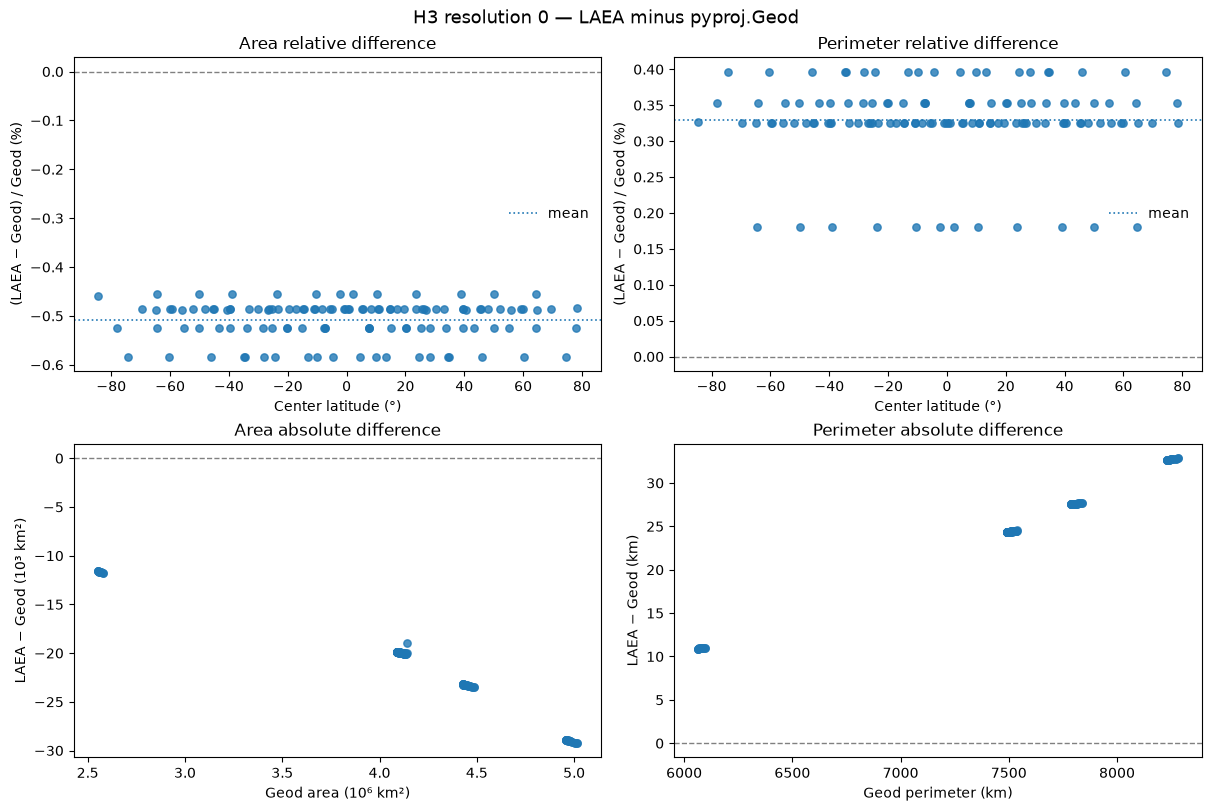

In [4]:
import matplotlib.pyplot as plt

cmp = cmp.copy()
cmp["area_diff_km2"] = cmp["area_laea_km2"] - cmp["area_geod_km2"]
cmp["perim_diff_km"] = cmp["perim_laea_km"] - cmp["perim_geod_km"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

ax = axes[0, 0]
ax.axhline(0, color="0.5", ls="--", lw=1)
ax.axhline(cmp["area_rel_err"].mean() * 100, color="C0", ls=":", lw=1.2, label="mean")
ax.scatter(cmp["center_lat"], cmp["area_rel_err"] * 100, s=28, alpha=0.8)
ax.set_xlabel("Center latitude (°)")
ax.set_ylabel("(LAEA − Geod) / Geod (%)")
ax.set_title("Area relative difference")
ax.legend(frameon=False)

ax = axes[0, 1]
ax.axhline(0, color="0.5", ls="--", lw=1)
ax.axhline(cmp["perim_rel_err"].mean() * 100, color="C0", ls=":", lw=1.2, label="mean")
ax.scatter(cmp["center_lat"], cmp["perim_rel_err"] * 100, s=28, alpha=0.8)
ax.set_xlabel("Center latitude (°)")
ax.set_ylabel("(LAEA − Geod) / Geod (%)")
ax.set_title("Perimeter relative difference")
ax.legend(frameon=False)

ax = axes[1, 0]
ax.axhline(0, color="0.5", ls="--", lw=1)
ax.scatter(cmp["area_geod_km2"] / 1e6, cmp["area_diff_km2"] / 1e3, s=28, alpha=0.8)
ax.set_xlabel("Geod area (10⁶ km²)")
ax.set_ylabel("LAEA − Geod (10³ km²)")
ax.set_title("Area absolute difference")

ax = axes[1, 1]
ax.axhline(0, color="0.5", ls="--", lw=1)
ax.scatter(cmp["perim_geod_km"], cmp["perim_diff_km"], s=28, alpha=0.8)
ax.set_xlabel("Geod perimeter (km)")
ax.set_ylabel("LAEA − Geod (km)")
ax.set_title("Perimeter absolute difference")

fig.suptitle("H3 resolution 0 — LAEA minus pyproj.Geod", fontsize=13)
plt.show()